# Interactive Notebook 05 - PMSM operation point selection:

This interactive Jupyter notebook introduces the concept of operating point selection for permanent magnet synchronous motors.

For help with the installation of the required software, consider the comments in ```CTPD_course\interactive_notebooks\README.md```.
Throughout the exercises, we will be using a combination of scientific computation libraries from the [JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) ecosystem and visualize them with [matplotlib](https://matplotlib.org/) and [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/).

### Preliminaries & Imports:

In [1]:
# automatically reloads imported ```.py```-files once they are changed and saved
%load_ext autoreload
%autoreload 2

In [2]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
</style>

In [3]:
# imports required packages
from functools import partial
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.io import loadmat
from pathlib import Path
from matplotlib import rc
import numpy as np
mpl.rcParams.update({'font.size': 20})

import jax
jax.config.update("jax_enable_x64", False)

import jax.numpy as jnp
import jaxopt
import equinox as eqx
import diffrax

(**Optional**: If you have LaTeX installed, you can use the following lines for pretty rendering of plot labels.
Any LaTeX installation should work, as long as all the required packages are installed, e.g., [MiKTeX](https://miktex.org/) or [TeXLive](https://www.tug.org/texlive/).

If you do not have LaTeX installed, you can comment the next cell out or skip it.)

In [4]:
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

---

**Throught the whole notebook, we will assume that the rotation speed $\omega$ can be set arbitrarily from an external load machine.**

### Operating point selection for the nonlinear PMSM:

We will use an adapted implementation from inb03 as our plant to be controlled (code in `utils/pmsm.py`) and the current controller from inb04 (code in `utils/current_controller.py`).

Now we want to control the system to produce a specific torque $T$.

We are looking at the operating point selection (OPS) component of our complete control structure:

<div>
<img src="fig/OPS_structure_diagramm.png" width="1000"/>
</div>

In [5]:
# auxiliary simulation code for the PMSM and the controller will is placed in `CTPD/interactive_notebooks/utils/`
import sys

from path_helper import get_folder_path
sys.path.insert(1, str(get_folder_path()))

In [6]:
from utils.pmsm import PMSM, lut_interpolate, clip_voltage
from utils.motor_params import MotorVariant
from utils.visualization import visualize_trajectories, visualize_trajectories_with_reference, add_voltage_constraint_to_ax
from utils.signals import aprbs
from utils.current_controller import FOCController

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Below we initialize the PMSM simulator and the current controller that you already know from the previous notebooks.

In [7]:
pmsm = PMSM(
    saturated=True,
    motor_variant=MotorVariant.BRUSA,
    T_s=1e-4,
)
pmsm

PMSM(
  T_s=0.0001,
  _solver=Euler(),
  env_properties=PMSM.EnvProperties(
    saturated=True,
    static_params=PMSM.StaticParams(
      p=weak_i32[],
      r_s=weak_f32[],
      l_d=weak_f32[],
      l_q=weak_f32[],
      psi_p=weak_f32[],
      u_dc=weak_i32[],
      i_lim=weak_i32[]
    )
  ),
  action_dim=2,
  physical_state_dim=5,
  LUT_grids={
    'L_dd': (f32[28], f32[53]),
    'L_dq': (f32[28], f32[53]),
    'L_qd': (f32[28], f32[53]),
    'L_qq': (f32[28], f32[53]),
    'Psi_d': (f32[28], f32[53]),
    'Psi_q': (f32[28], f32[53])
  },
  LUT_values={
    'L_dd': f32[28,53],
    'L_dq': f32[28,53],
    'L_qd': f32[28,53],
    'L_qq': f32[28,53],
    'Psi_d': f32[28,53],
    'Psi_q': f32[28,53]
  }
)

In [8]:
current_controller = FOCController(
    static_params=pmsm.env_properties.static_params,
    lut_grids=pmsm.LUT_grids,
    lut_values=pmsm.LUT_values,
    T_s=pmsm.T_s,
    d=0.99,
    rho=0.25,
    use_ARW=True,
) 
current_controller

Now we want to build a structure that computes target currents based on a target torque.
The plan is to build a real-time capable mapping $T^* \rightarrow i^*$ in the form of look-up-tables (LUTs).

The structure of the LUT-based OPS is:

<div>
<img src="fig/LUT-based_OPS.jpg" width="1000"/>
</div>

We need to compute 3 LUTs to be able to use this.

The `flux_MTPC_LUT`:
$$ \large \psi^*_{\mathrm{MTPC}} (T^*) = \| \boldsymbol{\psi}_{\mathrm{s, dq}} (\boldsymbol{i}^*_{\mathrm{MTPC}} (T^*))\|$$
which yields the required flux magnitude for the requested torque.

The `torque_MTPV_LUT`:
$$ \large T_{\mathrm{lim}} (\psi_{\mathrm{lim}}) = \max_{\boldsymbol{i}} T(\boldsymbol{i})$$
which yields maximum achievable torque for a given $\psi_{\mathrm{lim}} \approx u_{\mathrm{max}} / \omega$.

The `flux_torque_to_current_LUT`:
$$ \large \begin{bmatrix} i^*_{\mathrm{s,d}} & i^*_{\mathrm{s,q}} \end{bmatrix} = f(\psi^*_{\mathrm{lim}}, T^*_{\mathrm{lim}})$$
which yields the current operating point in the feasible operating region.

#### Visualize torque isolines:

In [9]:
i_d, i_q = pmsm.LUT_grids["L_dd"]
i_d, i_q = jnp.meshgrid(i_d, i_q)

print(i_d.shape)
print(i_q.shape)

# double vmap to vectorize over both axes of the current input arrays
torques = eqx.filter_vmap(eqx.filter_vmap(pmsm.currents_to_torque_saturated))(i_d, i_q)
print(torques.shape)

(53, 28)
(53, 28)
(53, 28)


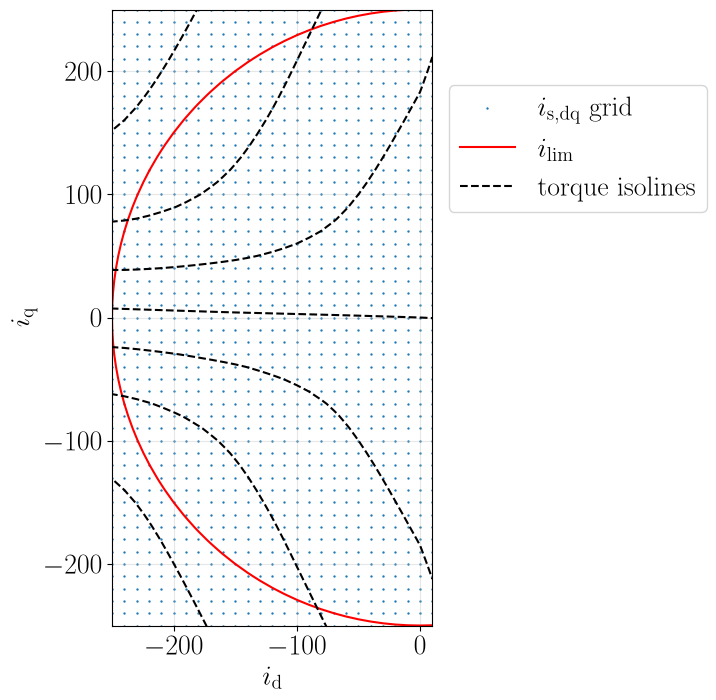

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")

scatter = ax.scatter(i_d, i_q, s=0.5, label=r"$i_\mathrm{s, dq}$ grid")

ax.contour(
    i_d, i_q, jnp.sqrt(i_d**2 + i_q**2), levels=[pmsm.env_properties.static_params.i_lim], colors="red", linewidths=1.5,
)
ax.contour(i_d, i_q, torques, linestyles="dashed", colors="k")

# Create proxy artists for the legend
lim_proxy = mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$")
torque_proxy = mlines.Line2D([], [], color="k", linestyle="dashed", label="torque isolines")

# Add legend using proxy artists
ax.legend(
    handles=[scatter, lim_proxy, torque_proxy],
    bbox_to_anchor=[1.9, 0.9]
)

ax.set_ylim((-250, 250))
ax.set_xlim((-250, 10))

ax.set_aspect("equal")

The black, dashed lines show the torque isolines (i.e., along the lines the torque is constant), in red we can see the current limit.

In [11]:
from interpax import Interpolator1D, Interpolator2D

#### `flux_MTPC_LUT`:  $\quad \large \psi^*_\mathrm{MTPC}(T^*) $

We compute this LUT by optimizing for the minimal current that produces the required torque (see, e.g., slide 279 in the lecture):

$$ \large \boldsymbol{i}_\mathrm{MTPC}(T^*) = \min_\boldsymbol{i} \| \boldsymbol{i}\|^2_2 \qquad \mathrm{s.t.} \quad T(\boldsymbol{i}) = T^*.$$

Then we can compute the corresponding flux via

$$ \large \psi^*_{\mathrm{MTPC}} (T^*) = \| \boldsymbol{\psi}_{\mathrm{s, dq}} (\boldsymbol{i}^*_{\mathrm{MTPC}} (T^*))\|.$$

The optimization problem is defined in the cell below. It uses an augmented Lagrangian formulation to solve the constrained optimization problem.

For reference on the augmented Lagrangian formulation you may look into `Nocedal2006` or e.g. `Bertsekas1982`, however, the implementation details of the optimization procedure are not in focus here.

```
@book{nocedal2006numerical,
  title={Numerical optimization},
  author={Nocedal, Jorge and Wright, Stephen J},
  year={2006},
  publisher={Springer}
}
```

```
@book{Bertsekas1982,
  title={Constrained optimization and Lagrange multiplier methods},
  author={Bertsekas, Dimitri P},
  year={1982},
  publisher={Academic press}
}
```

In [12]:
def objective(i_dq):
    """Optimization objective: Minimize the current magnitude."""
    return jnp.sum(i_dq**2)

def constraint(i_dq, torque_target, pmsm):
    """
    The objective is to minimized subject to the constraint that a chosen current
    should produce the requested current.
    """
    torque_est = pmsm.currents_to_torque_saturated(i_dq[0], i_dq[1])
    return jnp.squeeze(torque_target - torque_est)

def augmented_lagrangian(i_dq, lam, rho, torque_target, pmsm):
    """Augmented lagrangian to combine the objective and the constraint into a single
    optimization function.
    """
    h = constraint(i_dq, torque_target, pmsm)
    return objective(i_dq) + lam * h + (rho / 2.0) * h**2

@eqx.filter_jit
def optimize_single(torque_target, i_dq_init):
    """Optimization routine where the LBFGS optimizer is applied repeatedly onto the problem.
    In each iteration the parameters 'rho' and 'lam' are updated.
    """
    def al_step(i, state):
        i_dq, lam, rho, prev_viol = state

        solver = jaxopt.LBFGS(
            fun=lambda i_dq: augmented_lagrangian(i_dq, lam, rho, torque_target, pmsm),
            maxiter=300, tol=1e-7,
        )
        i_dq = solver.run(i_dq).params

        viol = constraint(i_dq, torque_target, pmsm)
        rho  = jnp.where(jnp.abs(viol) > 0.25 * jnp.abs(prev_viol), jnp.minimum(rho * 1.5, 1e2), rho)
        lam  = jnp.clip(lam + rho * viol, -1e3, 1e3)
        return i_dq, lam, rho, viol

    init_state = (i_dq_init, 0.0, 1.0, jnp.inf)
    i_dq, lam, rho, viol = jax.lax.fori_loop(0, 40, al_step, init_state)
    return i_dq

@eqx.filter_jit
def get_flux(i_dq, pmsm):
    """Get flux magnitude from currents."""
    p_d = {q: lut_interpolate(*pmsm.LUT_grids[q], pmsm.LUT_values[q], *i_dq) for q in pmsm.LUT_grids}
    psi_dq = jnp.column_stack([p_d[q] for q in ["Psi_d", "Psi_q"]])
    
    return jnp.sqrt(jnp.sum(psi_dq**2))

To produce a LUT from the optimization problem, we define a set of torque support points.

In [13]:
N_T = 201
T_lut = jnp.linspace(jnp.min(torques) * 0.9, jnp.max(torques) * 0.9, N_T)

torque_targets = T_lut
i_dq_inits = jnp.ones((T_lut.shape[0], 2)) * 0.1

optimize_batch = eqx.filter_vmap(optimize_single)

Now the optimization problem for each support point is solved, i.e., the $\boldsymbol{i}_\mathrm{dq}$ with minimal magnitude that produces the requested torque is searched for:

In [14]:
i_dq_solutions = optimize_batch(torque_targets, i_dq_inits)

Only solutions that are within the current limit are kept.

In [15]:
mask_valid = jnp.sqrt(jnp.sum(i_dq_solutions**2, axis=-1)) <= pmsm.env_properties.static_params.i_lim
i_dq_valid = i_dq_solutions[mask_valid]
T_lut = T_lut[mask_valid]

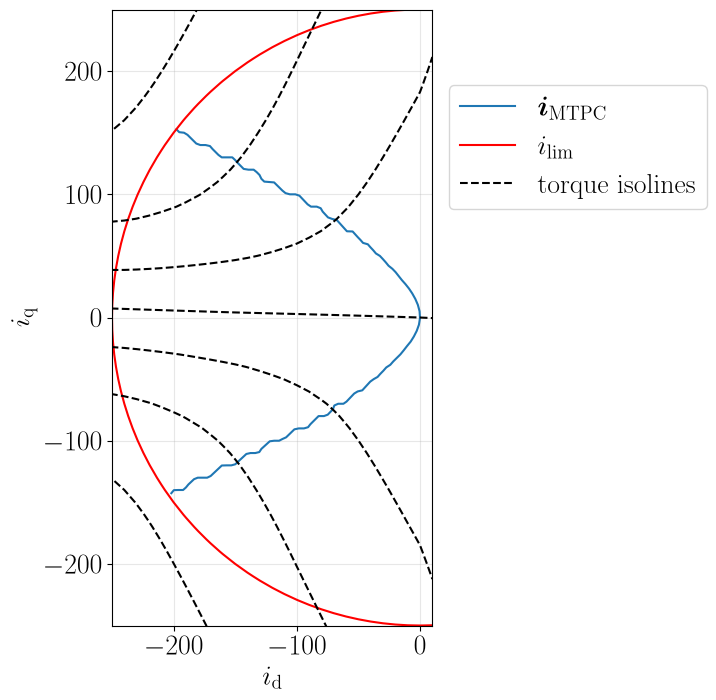

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")

line = ax.plot(i_dq_valid[:, 0], i_dq_valid[:, 1])

ax.contour(
    i_d, i_q, jnp.sqrt(i_d**2 + i_q**2), levels=[pmsm.env_properties.static_params.i_lim], colors="red", linewidths=1.5,
)
ax.contour(i_d, i_q, torques, linestyles="dashed", colors="k")

# Create proxy artists for the legend
line_proxy = mlines.Line2D([], [], color="tab:blue", linewidth=1.5, label=r"$\boldsymbol{i}_\mathrm{MTPC}$")
lim_proxy = mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$")
torque_proxy = mlines.Line2D([], [], color="k", linestyle="dashed", label="torque isolines")

# Add legend using proxy artists
ax.legend(
    handles=[line_proxy, lim_proxy, torque_proxy],
    bbox_to_anchor=[1.9, 0.9]
)

ax.set_ylim((-250, 250))
ax.set_xlim((-250, 10))

ax.set_aspect("equal")

Compute the flux values from the optimized currents:

$$ \large \psi^*_{\mathrm{MTPC}} (T^*) = \| \boldsymbol{\psi}_{\mathrm{s, dq}} (\boldsymbol{i}^*_{\mathrm{MTPC}} (T^*))\|.$$

In [17]:
psi_MTPC_lut = eqx.filter_vmap(get_flux, in_axes=(0, None))(i_dq_valid, pmsm)

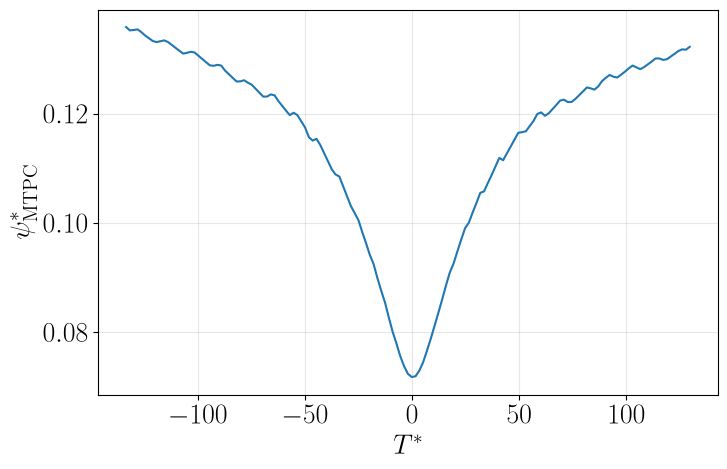

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"$T^*$")
ax.set_ylabel(r"$\psi^*_\mathrm{MTPC}$")

plt.plot(T_lut, psi_MTPC_lut)

In [19]:
i_dq_valid_MTPC = i_dq_valid

Setup the interpolator for the LUT:

In [20]:
flux_MTPC_LUT = Interpolator1D(x=T_lut, f=psi_MTPC_lut, extrap=True, method="linear")
flux_MTPC_LUT

Interpolator1D(
  method='linear',
  x=f32[149],
  f=f32[149],
  derivs={'fx': f32[149]},
  extrap=True,
  period=None,
  axis=0
)

In [21]:
torque_target = 12.4
necessary_flux = flux_MTPC_LUT(torque_target)
necessary_flux

Array(0.0836856, dtype=float32)

Now we are done with the first LUT.

#### `torque_MTPV_LUT`: $\quad \large T_\mathrm{lim} (\psi^*_\mathrm{lim})$

This LUT provides the maximum torque that can be produced with the given flux.
Once more, it is computed using an numerical optimization procedure.
The maximum torque is to be produced, while the flux magnitude stays below $\psi_\mathrm{lim} = u_\mathrm{max} / \omega$ and the current constraints are respected.

$$ \large T_{\mathrm{lim}} (\psi_{\mathrm{lim}}) = \max_{\boldsymbol{i}} T(\boldsymbol{i})  \qquad \mathrm{s.t.} \quad \|\boldsymbol{\psi}(\boldsymbol{i})\|_2 \leq \psi_\mathrm{lim}, \quad \|\boldsymbol{i}\|_2 \leq i_\mathrm{lim} $$

Once more, the optimization is done in a augmented Lagrangian formulation, but the details of the optimization implementation are not in focus.

In [22]:
def objective(i_dq, pmsm, positive_torques):
    """The optimization objective. Since our optimizer is implemented to minimize functions, the sign for the output torque is flipped.
    When the LUT is computed for negative torques, we do not need to flip the sign, as we minimize in this case.
    """
    
    torque = pmsm.currents_to_torque_saturated(*i_dq)

    if positive_torques:
        return - torque  # maximize the torque, so minimize negative torque
    else:
        return torque # minimize the torque (negative values, i.e., optimization towards larger negative torque)

def constraints(i_dq, psi_lim, pmsm):
    """Here, we have two inequality constraints. The flux magnitude needs to stay below psi_lim and the currents need to stay
    below the current limit.
    """

    i_lim = pmsm.env_properties.static_params.i_lim
    
    psi = get_flux(i_dq, pmsm)
    h1 = (psi - psi_lim) * 1e3
    h2 = jnp.linalg.norm(i_dq) - i_lim

    return jnp.array([h1, h2])

def augmented_lagrangian(i_dq, psi_lim, lam, rho, pmsm, positive_torques):
    """Augmented lagrangian formulation for the inequality constrained objective."""
    
    h = constraints(i_dq, psi_lim, pmsm)
    al_ineq = jnp.where(
        lam + rho * h > 0,               # Checks if constraint is active
        lam * h + (rho / 2.0) * h**2,    # active: penalize
        -lam**2 / (2.0 * rho),           # inactive: constant value
    )
    return objective(i_dq, pmsm, positive_torques) + jnp.sum(al_ineq)

@eqx.filter_jit
def optimize_single(psi_lim, i_dq_init, pmsm, positive_torques=True):
    """Optimization procedure."""
    
    def al_step(i, state):
        i_dq, lam, rho, prev_viol = state

        solver = jaxopt.LBFGS(
            fun=lambda i_dq: augmented_lagrangian(i_dq, psi_lim, lam, rho, pmsm, positive_torques),
            maxiter=300, tol=1e-7,
        )
        i_dq = solver.run(i_dq).params

        h = constraints(i_dq, psi_lim, pmsm)
        viol = jnp.linalg.norm(jnp.maximum(h, 0.0))
        rho = jnp.where(viol > 0.25 * prev_viol, jnp.minimum(rho * 1.5, 1e2), rho)
    
        lam = jnp.maximum(lam + rho * h, 0.0)
        lam = lam * (h >= 0).astype(jnp.float32)
        return i_dq, lam, rho, viol

    init_state = (i_dq_init, jnp.zeros(2), 1.0, jnp.inf)
    i_dq, lam, rho, viol = jax.lax.fori_loop(0, 40, al_step, init_state)
    return i_dq

First, we define a set of flux support points for the LUT. Then the optimization problem is solved for all of them targeting positive torque values.

In [23]:
N_psi = 201

psi_max = jnp.max(jnp.sqrt(pmsm.LUT_values["Psi_d"]**2 + pmsm.LUT_values["Psi_q"]**2))

psi_LUT = jnp.linspace(0, 0.99 * psi_max, N_psi)
i_dq_inits = jnp.ones((psi_LUT.shape[0], 2)) * jnp.array([-100, 100])

psi_limits = psi_LUT
optimize_batch = eqx.filter_vmap(optimize_single, in_axes=(0,0,None,None))

i_dq_solutions_positive_torque = optimize_batch(psi_limits, i_dq_inits, pmsm, True)
mask_valid_positive_torque = jnp.sqrt(jnp.sum(i_dq_solutions_positive_torque**2, axis=-1)) <= pmsm.env_properties.static_params.i_lim

Then the process is repeated for negative torque targets.

In [24]:
N_psi = 201

psi_max = jnp.max(jnp.sqrt(pmsm.LUT_values["Psi_d"]**2 + pmsm.LUT_values["Psi_q"]**2))

psi_LUT = jnp.linspace(0, 0.99 * psi_max, N_psi)
i_dq_inits = jnp.ones((psi_LUT.shape[0], 2)) * jnp.array([-100, 100])

psi_limits = psi_LUT
optimize_batch = eqx.filter_vmap(optimize_single, in_axes=(0,0,None,None))

i_dq_solutions_negative_torque = optimize_batch(psi_limits, i_dq_inits, pmsm, False)
mask_valid_negative_torque = jnp.sqrt(jnp.sum(i_dq_solutions_negative_torque**2, axis=-1)) <= pmsm.env_properties.static_params.i_lim

Only currents within the current limit are retained and the results for positive and negative torques are placed into one vector:

In [25]:
psi_MTPV_lut = psi_LUT[mask_valid_positive_torque]
i_dq_valid = jnp.concatenate([
    i_dq_solutions_negative_torque[mask_valid_negative_torque][::-1],
    i_dq_solutions_positive_torque[mask_valid_positive_torque]
])

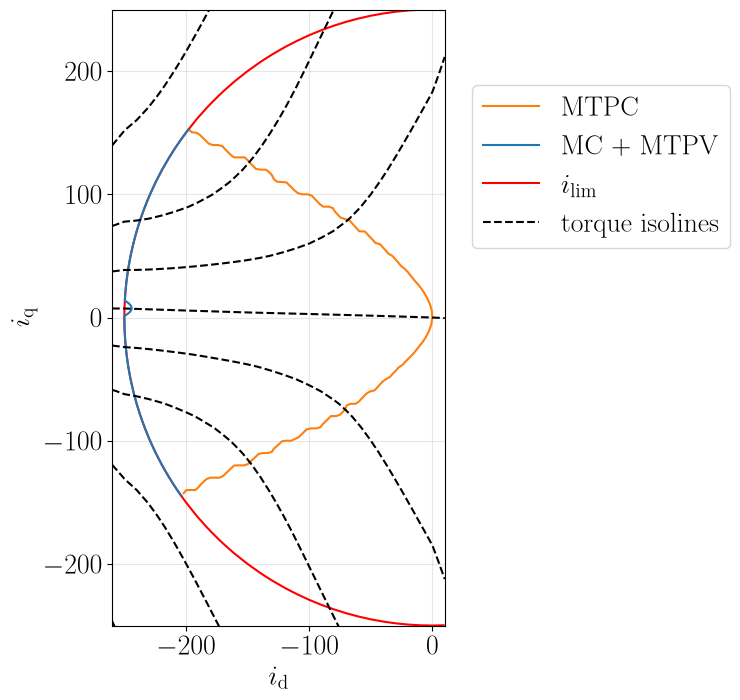

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")

line_MTPC = ax.plot(i_dq_valid_MTPC[:, 0], i_dq_valid_MTPC[:, 1], color="tab:orange")
ax.contour(i_d, i_q, jnp.sqrt(i_d**2 + i_q**2), levels=[pmsm.env_properties.static_params.i_lim], colors="red", linewidths=1.5)
line_MC_MTPV = ax.plot(i_dq_valid[:, 0], i_dq_valid[:, 1], color="tab:blue")
ax.contour(i_d, i_q, torques, linestyles="dashed", colors="k")

# Create proxy artists for the legend
line_MTPC_proxy = mlines.Line2D([], [], color="tab:orange", linewidth=1.5, label="MTPC")
line_MC_MTPV_proxy = mlines.Line2D([], [], color="tab:blue", linewidth=1.5, label="MC + MTPV")
lim_proxy = mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$")
torque_proxy = mlines.Line2D([], [], color="k", linestyle="dashed", label="torque isolines")

# Add legend using proxy artists
ax.legend(
    handles=[line_MTPC_proxy, line_MC_MTPV_proxy, lim_proxy, torque_proxy],
    bbox_to_anchor=[1.9, 0.9]
)


ax.set_ylim((-250, 250))
ax.set_xlim((-260, 10))

ax.set_aspect("equal")

plt.savefig("BRUSA_MTPC_MC_MTPV.pdf", bbox_inches="tight")

Compute the resulting torque values from the optimized currents:

In [27]:
T_MTPV_lut = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(i_dq_solutions_positive_torque[mask_valid_positive_torque][:, 0], i_dq_solutions_positive_torque[mask_valid_positive_torque][:, 1])

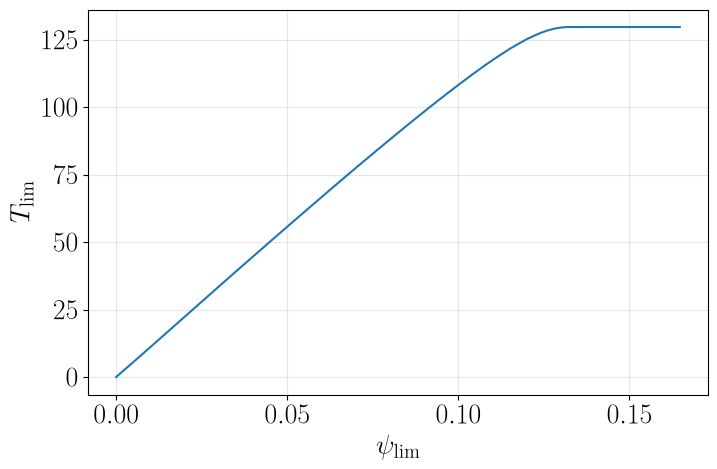

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"$T_\mathrm{lim}$")
ax.set_xlabel(r"$\psi_\mathrm{lim}$")

plt.plot(psi_MTPV_lut, T_MTPV_lut)

Setup the interpolator for the LUT:

In [29]:
torque_MTPV_LUT = Interpolator1D(x=psi_MTPV_lut, f=T_MTPV_lut, extrap=True, method="linear")
torque_MTPV_LUT

Interpolator1D(
  method='linear',
  x=f32[147],
  f=f32[147],
  derivs={'fx': f32[147]},
  extrap=True,
  period=None,
  axis=0
)

In [30]:
available_flux = 0.089
resulting_torque_limit = torque_MTPV_LUT(available_flux)
resulting_torque_limit

Array(97.291954, dtype=float32)

Now we are done with the second LUT.

#### `flux_torque_to_current_LUT`: $ \large \begin{bmatrix} i^*_{\mathrm{s,d}} & i^*_{\mathrm{s,q}} \end{bmatrix} = f(\psi^*_{\mathrm{lim}}, T^*_{\mathrm{lim}})$

The final LUT is a direct mapping from the available flux and the clipped torque reference to the current operation point.

We do not need to solve an optimization problem here. We can simply compute the forward pass from currents to torque and flux and then invert the mapping.

In [31]:
@eqx.filter_jit
def get_flux_and_torque(i_dq, pmsm):
    """Computes flux magnitude and torque for a specified current."""
    flux = get_flux(i_dq, pmsm)
    torque = pmsm.currents_to_torque_saturated(i_dq[0], i_dq[1])
    
    return jnp.stack([flux, torque], axis=-1)

First, we compute the flux and torque for a grid of current values.

In [32]:
i_d_values = jnp.linspace(-260, 10, 1000)
i_q_values = jnp.linspace(-260, 260, 1000)
i_dq_grid = jnp.stack(jnp.meshgrid(i_d_values, i_q_values, indexing="ij"), axis=-1)

flux_torque_values = eqx.filter_vmap(
    eqx.filter_vmap(
        get_flux_and_torque,
        in_axes=(0, None),
    ), 
    in_axes=(0, None),
)(i_dq_grid, pmsm)

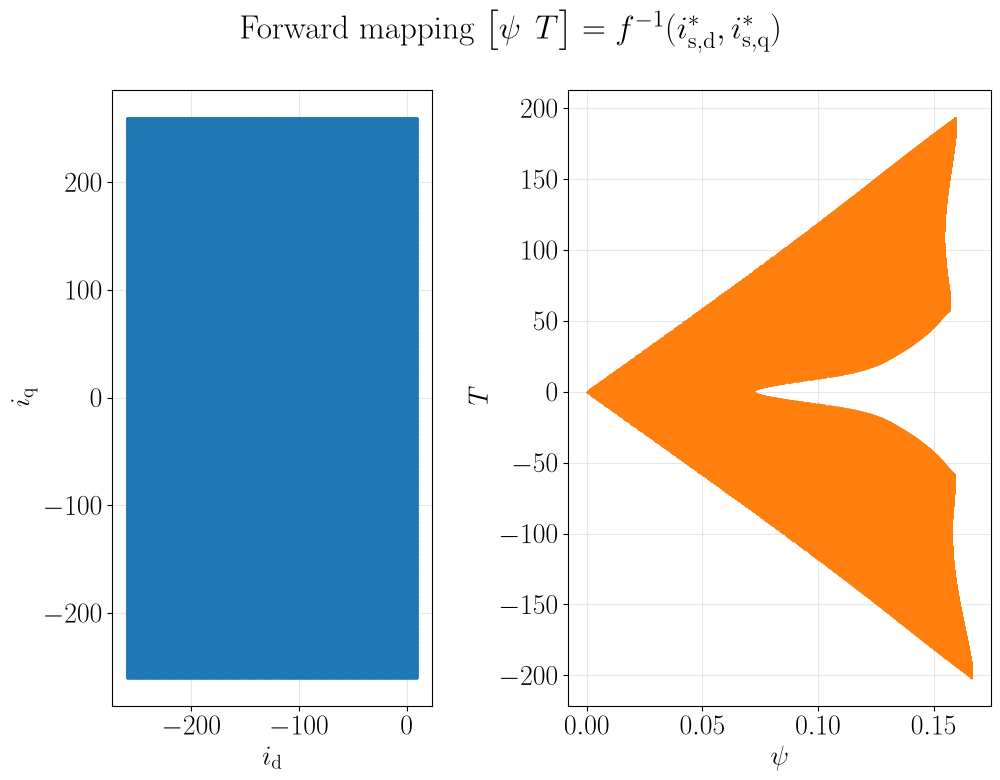

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

for ax in axs:
    ax.grid(True, alpha=0.3)

ax = axs[0]
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")
ax.plot(
    i_dq_grid.reshape((-1,2))[:, 0],
    i_dq_grid.reshape((-1,2))[:, 1],
    marker=".",
    color="tab:blue",
    linestyle="",
    markersize=0.5,
)
ax.set_aspect("equal")

ax = axs[1]
ax.plot(
    flux_torque_values.reshape((-1,2))[:, 0],
    flux_torque_values.reshape((-1,2))[:, 1],
    marker=".",
    color="tab:orange",
    linestyle="",
    markersize=0.5,
)
ax.set_xlabel(r"$\psi$")
ax.set_ylabel(r"$T$")

fig.suptitle(r"Forward mapping $\begin{bmatrix} \psi & T \end{bmatrix} = f^{-1}(i^*_{\mathrm{s,d}}, i^*_{\mathrm{s,q}})$")
plt.show()

In theory we could simply interpolate based on the computed torque-flux values.
Practically, it is preferable to have a regular spaced grid for interpolation.
Therefore, we create a regulargrid in the $\psi$-$T$-plane and then interpolate the corresponding currents.

In [34]:
from scipy.interpolate import LinearNDInterpolator

In [35]:
interp = LinearNDInterpolator(
    points=flux_torque_values.reshape((-1, 2)), 
    values=i_dq_grid.reshape((-1, 2)),
)

In [36]:
regular_flux_values = jnp.linspace(flux_torque_values[..., 0].min(), flux_torque_values[..., 0].max(), 500)
regular_torque_values = jnp.linspace(flux_torque_values[..., 1].min(), flux_torque_values[..., 1].max(), 500)
regular_flux_torque_grid = jnp.stack(jnp.meshgrid(regular_flux_values, regular_torque_values, indexing="ij"), axis=-1)
i_dq_interp_output = interp(regular_flux_torque_grid)

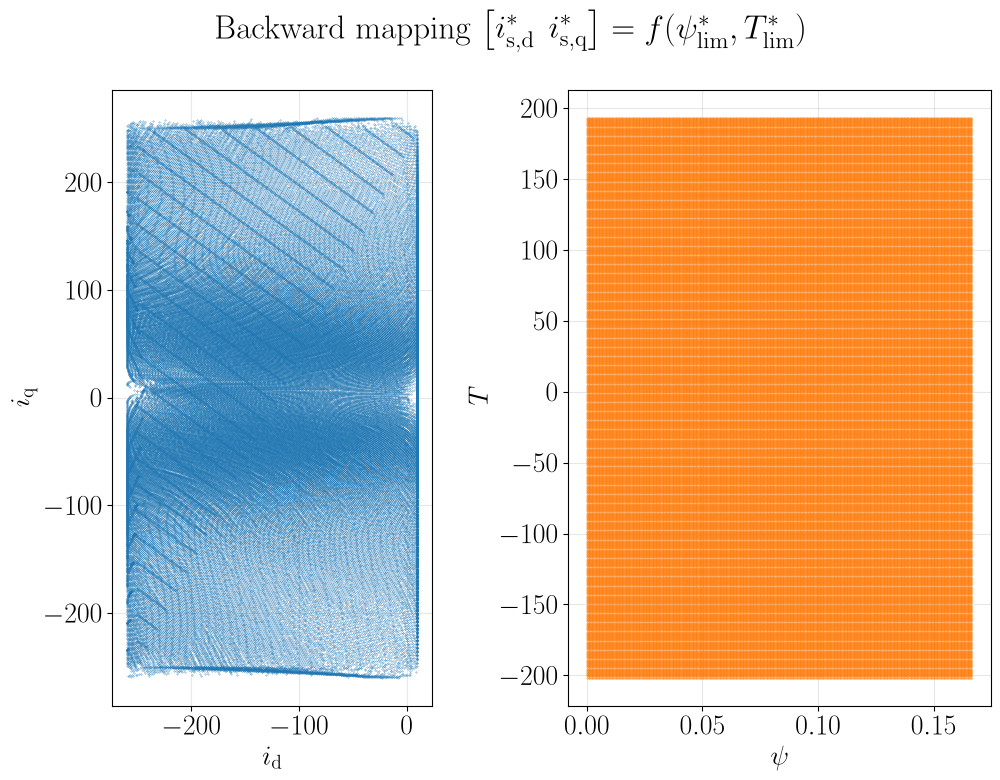

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

for ax in axs:
    ax.grid(True, alpha=0.3)

ax = axs[0]
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")
ax.plot(
    i_dq_interp_output.reshape((-1,2))[:, 0],
    i_dq_interp_output.reshape((-1,2))[:, 1],
    marker=".",
    color="tab:blue",
    linestyle="",
    markersize=0.5,
)
ax.set_aspect("equal")

ax = axs[1]
ax.plot(
    regular_flux_torque_grid.reshape((-1,2))[:, 0],
    regular_flux_torque_grid.reshape((-1,2))[:, 1],
    marker=".",
    color="tab:orange",
    linestyle="",
    markersize=0.5,
)
ax.set_xlabel(r"$\psi$")
ax.set_ylabel(r"$T$")

fig.suptitle(r"Backward mapping $ \begin{bmatrix} i^*_{\mathrm{s,d}} & i^*_{\mathrm{s,q}} \end{bmatrix} = f(\psi^*_{\mathrm{lim}}, T^*_{\mathrm{lim}})$")
plt.show()

Now we created a regular spaced grid in $\psi$-$T$ and an unregular output for the currents, which is preferable for interpolation.

Setup 2D interpolator:

In [38]:
flux_torque_to_current_LUT = Interpolator2D(
    x=regular_flux_values,
    y=regular_torque_values,
    f=i_dq_interp_output,
    extrap=True,
    method="linear"
)
flux_torque_to_current_LUT

Interpolator2D(
  method='linear',
  x=f32[500],
  y=f32[500],
  f=f32[500,500,2],
  derivs={'fx': f32[500,500,2], 'fy': f32[500,500,2], 'fxy': f32[500,500,2]},
  extrap=True,
  period=None,
  axis=0
)

In [39]:
available_flux = 0.05
clipped_target_torque = -27

print("available flux:", available_flux)
print("clipped target torque:", clipped_target_torque)

i_dq = flux_torque_to_current_LUT(available_flux, clipped_target_torque)
print("OP currents:", i_dq)

flux_torque = get_flux_and_torque(jnp.squeeze(i_dq), pmsm)
print("resulting flux:", flux_torque[0])
print("resulting torque:", flux_torque[1])

available flux: 0.05
clipped target torque: -27
OP currents: [-131.81532  -20.09117]
resulting flux: 0.05001271
resulting torque: -27.144922


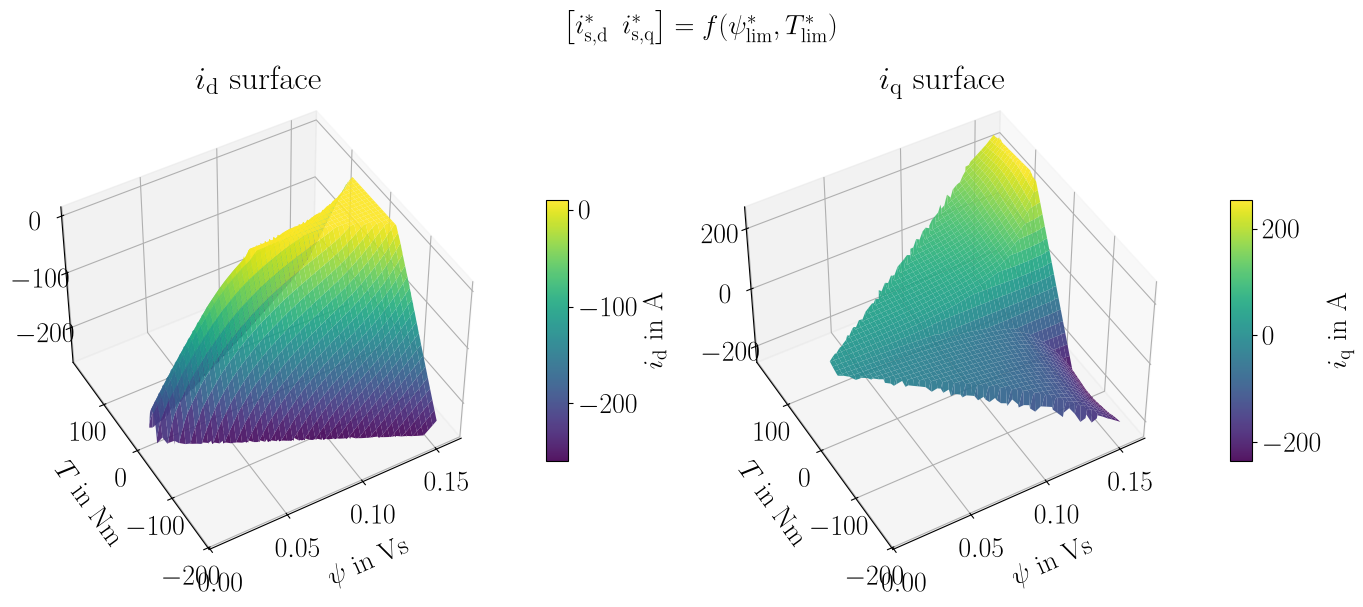

In [40]:
def plot_current_surfaces(
    regular_flux_values,
    regular_torque_values,
    flux_torque_to_current_LUT,
    figsize=(14, 6),
    cmap="viridis",
    edge_trim=0.02,
    elev=28,
    azim=-110,
):
    flux_all = jnp.asarray(regular_flux_values)      # (N_F,)
    torque_all = jnp.asarray(regular_torque_values)  # (N_T,)

    def _trim(arr, frac):
        lo = arr[0] + frac * (arr[-1] - arr[0])
        hi = arr[-1] - frac * (arr[-1] - arr[0])
        return jnp.linspace(lo, hi, len(arr))
 
    flux   = _trim(flux_all,   edge_trim)
    torque = _trim(torque_all, edge_trim)

    flux_grid, torque_grid = jnp.meshgrid(flux, torque, indexing="ij")
    flux_flat = flux_grid.ravel()
    torque_flat = torque_grid.ravel()

    batched_lut = jax.vmap(flux_torque_to_current_LUT)
    currents = batched_lut(flux_flat, torque_flat)

    i_d = np.array(currents[:, 0]).reshape(flux_grid.shape)
    i_q = np.array(currents[:, 1]).reshape(flux_grid.shape)

    X = np.array(flux_grid)
    Y = np.array(torque_grid)

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        subplot_kw={"projection": "3d"},
    )
    fig.suptitle(r"$\begin{bmatrix} i^*_{\mathrm{s,d}} & i^*_{\mathrm{s,q}} \end{bmatrix} = f(\psi^*_{\mathrm{lim}}, T^*_{\mathrm{lim}})$", fontsize=20, fontweight="bold")

    panels = [
        (axes[0], i_d, r"$i_\mathrm{d}$ in A",  r"$i_\mathrm{d}$ surface"),
        (axes[1], i_q, r"$i_\mathrm{q}$ in A",  r"$i_\mathrm{q}$ surface"),
    ]

    for ax, Z, zlabel, title in panels:
        surf = ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, antialiased=True, alpha=0.92)
        fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0.1, label=zlabel)
        ax.set_xlabel(r"$\psi$ in Vs", labelpad=14)
        ax.set_ylabel(r"$T$ in  Nm", labelpad=14)
        ax.set_title(title, pad=10)
        ax.view_init(elev=elev, azim=-azim)
    fig.tight_layout()
    return fig

fig = plot_current_surfaces(
    regular_flux_values,
    regular_torque_values,
    flux_torque_to_current_LUT,
    edge_trim=0.06,
    elev=45,
    azim=120,
)

Now we are done with the third LUT.

#### Full OPS:

Now that we have all LUTs together, we combine them to produce the full OPS structure:

In [41]:
@eqx.filter_jit
def get_current_operating_point(torque_target, omega, pmsm):
    flux_MTPC = flux_MTPC_LUT(torque_target)

    u_max = pmsm.env_properties.static_params.u_dc / jnp.sqrt(3)
    flux_max = u_max / (omega + 1e-8)
    flux_target_lim = jnp.minimum(flux_max, flux_MTPC)

    torque_max = torque_MTPV_LUT(flux_target_lim)
    
    torque_target_lim = jnp.clip(torque_target, min=-torque_max, max=torque_max)
    i_dq_target = flux_torque_to_current_LUT(flux_target_lim, torque_target_lim)
    return jnp.squeeze(i_dq_target), (flux_max, flux_target_lim, torque_max, torque_target_lim)

Forward pass through the OPS:
Here, you may test out how the OPS behaves depending on different target torques and rotation speed.

In [42]:
n = 4000
omega = jnp.array([pmsm.env_properties.static_params.p * n * 2 * jnp.pi / 60])

i_dq, (flux_max, flux_target_lim, torque_max, torque_target_lim) = get_current_operating_point(
    torque_target=jnp.array([150]),
    omega=omega,
    pmsm=pmsm,
)

i_dq, (flux_max, flux_target_lim, torque_max, torque_target_lim)

(Array([-182.18813,  175.66101], dtype=float32),
 (Array([0.18377629], dtype=float32),
  Array([0.1383035], dtype=float32),
  Array([129.64801], dtype=float32),
  Array([129.64801], dtype=float32)))

For the operating point at $n=4000 \; \mathrm{min}^{-1}$ and $T^* = 150 \; \mathrm{Nm}$, the targeted torque will not be possible.
The problem is that the torque cannot be produced with the available flux. 

As a result, the torque target is clipped to $T^* \approx 130 \; \mathrm{Nm}$.
Since the flux limit is not reached, we are not in flux-weakening operation and, therefore, the targeted torque of $T^* = 150 \; \mathrm{Nm}$ is never feasible.

In [43]:
flux_torque = get_flux_and_torque(i_dq, pmsm)
print("flux", flux_torque[0])
print("torque", flux_torque[1])

flux 0.13831408
torque 129.66267


The resulting current operating point does provide $T^* \approx 130 \; \mathrm{Nm}$.
That means that the OPS does behave as we would expect for this case.

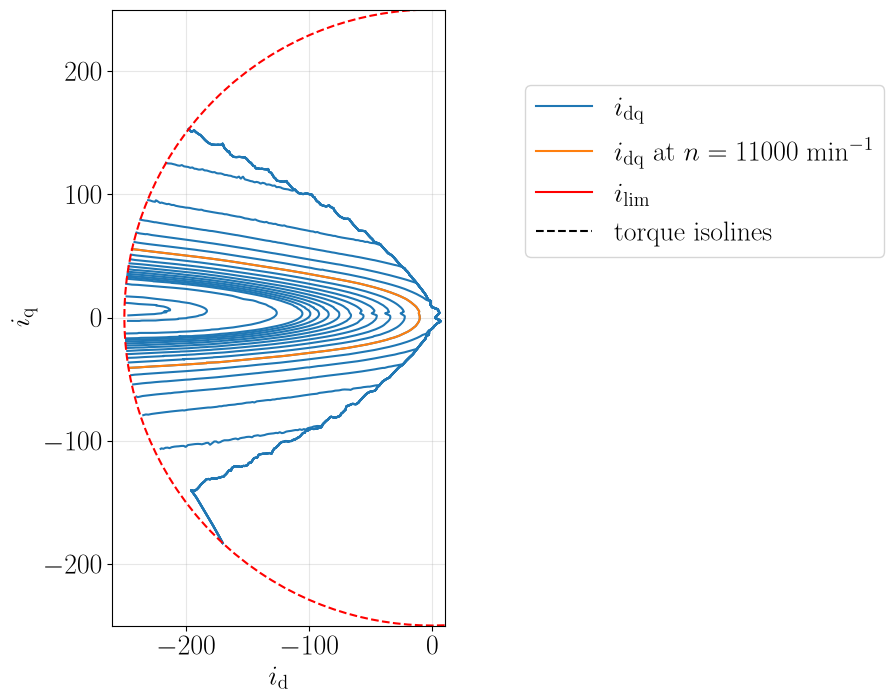

In [44]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"$i_\mathrm{d}$")
ax.set_ylabel(r"$i_\mathrm{q}$")


test_torques = jnp.linspace(-200, 200, 2000)[:, None]
for n in list(np.arange(0, 22_000, 1000)) + [25_000, 50_000, 100_000]:
    omega = jnp.array([pmsm.env_properties.static_params.p * n * 2 * jnp.pi / 60])

    i_dqs, _ = eqx.filter_vmap(get_current_operating_point, in_axes=(0, None, None))(test_torques, omega, pmsm)
    valid = jnp.logical_and((~jnp.isnan(i_dqs)).any(axis=-1), jnp.sqrt(jnp.sum(i_dqs**2, axis=-1)) <= pmsm.env_properties.static_params.i_lim)
    i_dqs = i_dqs[valid]
    line = ax.plot(i_dqs[:, 0], i_dqs[:, 1], color="tab:blue")


##

omega = jnp.array([pmsm.env_properties.static_params.p * 11000 * 2 * jnp.pi / 60])

i_dqs, _ = eqx.filter_vmap(get_current_operating_point, in_axes=(0, None, None))(test_torques, omega, pmsm)
valid = (~jnp.isnan(i_dqs)).any(axis=-1)
i_dqs = i_dqs[valid]
line = ax.plot(i_dqs[:, 0], i_dqs[:, 1], color="tab:orange")

ax.contour(i_d, i_q, jnp.sqrt(i_d**2 + i_q**2), levels=[pmsm.env_properties.static_params.i_lim], colors="red", linestyle="dashed", linewidths=1.5)

# Create proxy artists for the legend
line = mlines.Line2D([], [], color="tab:blue", linewidth=1.5, label=r"$i_{\mathrm{dq}}$")
line_max = mlines.Line2D([], [], color="tab:orange", linewidth=1.5, label=r"$i_{\mathrm{dq}}$ at $n = 11000 \; \mathrm{min}^{-1}$")
lim_proxy = mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$")
torque_proxy = mlines.Line2D([], [], color="k", linestyle="dashed", label="torque isolines")

# Add legend using proxy artists
ax.legend(
    handles=[line, line_max, lim_proxy, torque_proxy],
    bbox_to_anchor=[1.2, 0.9]
)


ax.set_ylim((-250, 250))
ax.set_xlim((-260, 10))

ax.set_aspect("equal")

In this figure, we can see a sweep through the torque operating range, which results in a current sweep for different rotation speeds (starting from $n = 0 \; \mathrm{min}^{-1}$ up to  $n = 50_000 \; \mathrm{min}^{-1}$ in blue).
In orange the case for the maximum speed at $n = 11000 \; \mathrm{min}^{-1}$ for the operation of the machine is shown.

### Full control structure:

Finally, we combine the OPS with the PMSM simulation and the current controller to simulate the complete control loop (under assumption of ideal inverter behavior).

In [45]:
def simulate_controller_plant_interaction(pmsm, controller, T_ref_sequence, n):
    obs, state = pmsm.reset() # puts the state back to the equilibrium point, zero-speed
    obs, state = pmsm.set_speed(n=n, state=state)

    integrated = controller.reset()
    i_dq = obs[:2]
    u_dq = jnp.array([0.0, 0.0])

    i_dq_sequence = [i_dq]
    u_dq_sequence = [u_dq]

    i_dq_ref_sequence, _ = eqx.filter_vmap(
        get_current_operating_point, in_axes=(0, None, None)
    )(T_ref_sequence, state.physical_state.omega_el, pmsm)
  
    for i_dq_ref in i_dq_ref_sequence:

        # controller chooses voltage to be applied in the next iteration
        u_dq_next, integrated = controller(
            i_dq,
            i_dq_ref,
            u_dq,
            state.physical_state.omega_el,
            state.physical_state.epsilon,
            integrated
        )

        # simulates the application of the voltage command chosen in the
        # last iteration
        obs, state = pmsm.step(state, u_dq)

        # prepare current and voltage for the next iteration
        i_dq_next = obs[:2]
        i_dq = i_dq_next
        u_dq = u_dq_next
        
        i_dq_sequence.append(i_dq)
        u_dq_sequence.append(u_dq)
    
    i_dq_sequence = jnp.array(i_dq_sequence)
    u_dq_sequence = jnp.array(u_dq_sequence)

    final_state = state
    return i_dq_sequence, u_dq_sequence, i_dq_ref_sequence, final_state

- `n = 500`:

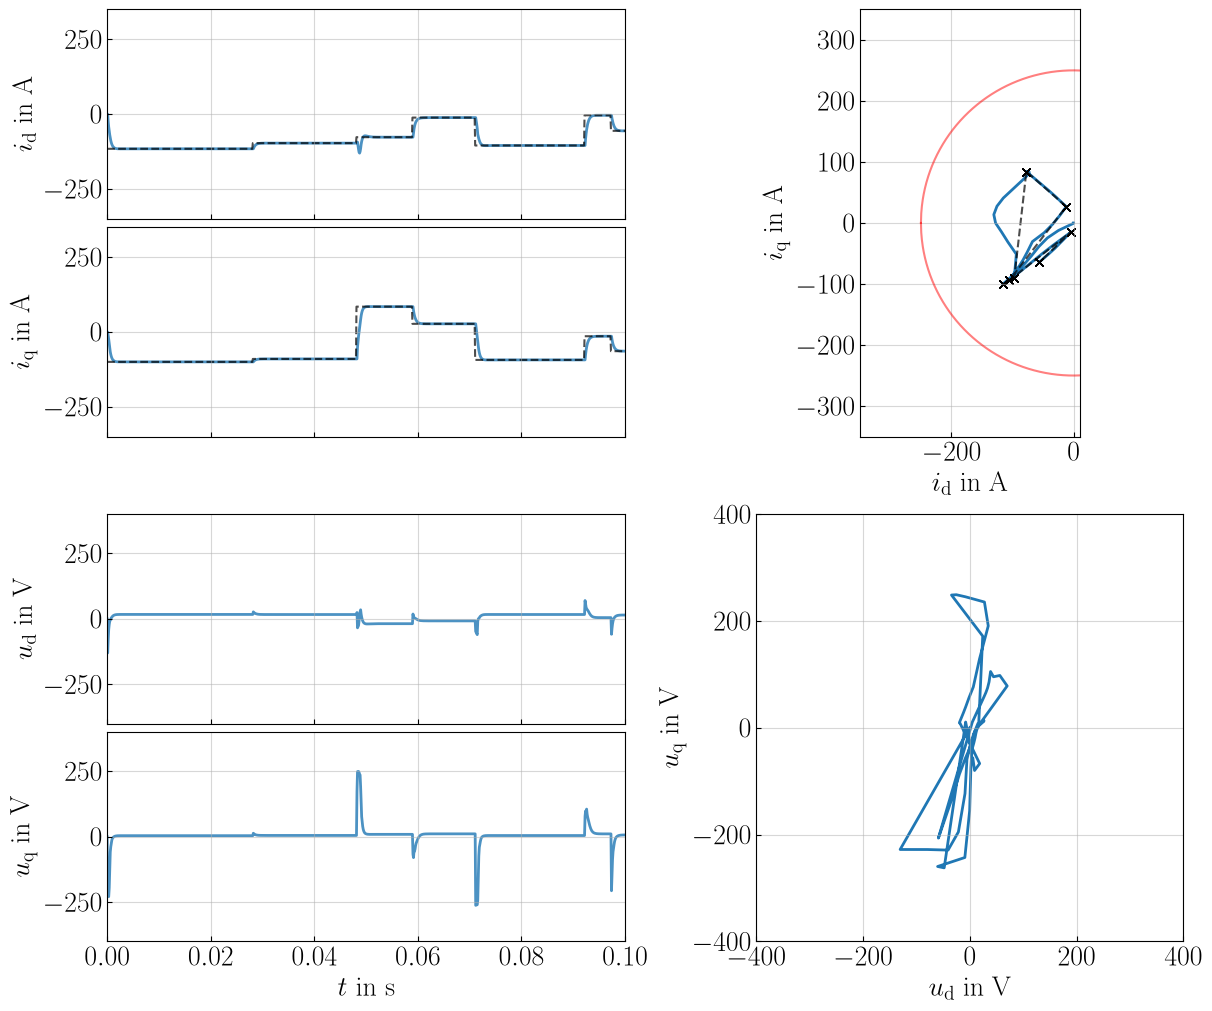

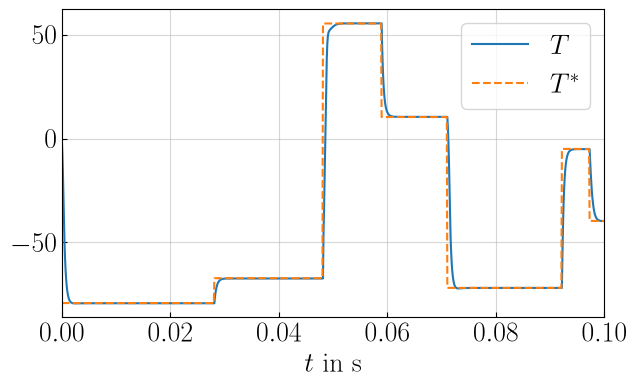

In [46]:
# compute reference
sequence_length = 1_000
T_ref_sequence = aprbs(sequence_length, 1, t_min=50, t_max=300, key=jax.random.key(0)).T[0] * 100

# run simulation
i_dq_sequence, u_dq_sequence, i_dq_ref_sequence, state = simulate_controller_plant_interaction(
    pmsm=pmsm,
    controller=current_controller,
    T_ref_sequence=T_ref_sequence,
    n=500,
)

# visualize results
visualize_trajectories_with_reference(
    i_dq_sequences=[i_dq_sequence],
    u_dq_sequences=[u_dq_sequence], 
    i_dq_ref_sequence=i_dq_ref_sequence,
    T_s_list=[pmsm.T_s],
    omegas=[state.physical_state.omega_el],
    ode=None,
    params=pmsm.env_properties.static_params,
)

torque_sequence = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(
    i_dq_sequence[1:, 0], i_dq_sequence[1:, 1]
)

t = jnp.linspace(0, (pmsm.T_s * sequence_length), sequence_length)

fig, ax = plt.subplots(1,1, figsize=(7, 4))


ax.plot(t, torque_sequence, color="tab:blue", label=r"$T$")
ax.plot(t, T_ref_sequence, linestyle="dashed", color="tab:orange", label=r"$T^*$")
ax.set_xlim(t[0], t[-1])

ax.grid(True, alpha=0.5)
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")
ax.set_xlabel("$t$ in s")
ax.legend()
plt.show()

Here, we can see that current and torque are followed properly.

- `n = 5000`

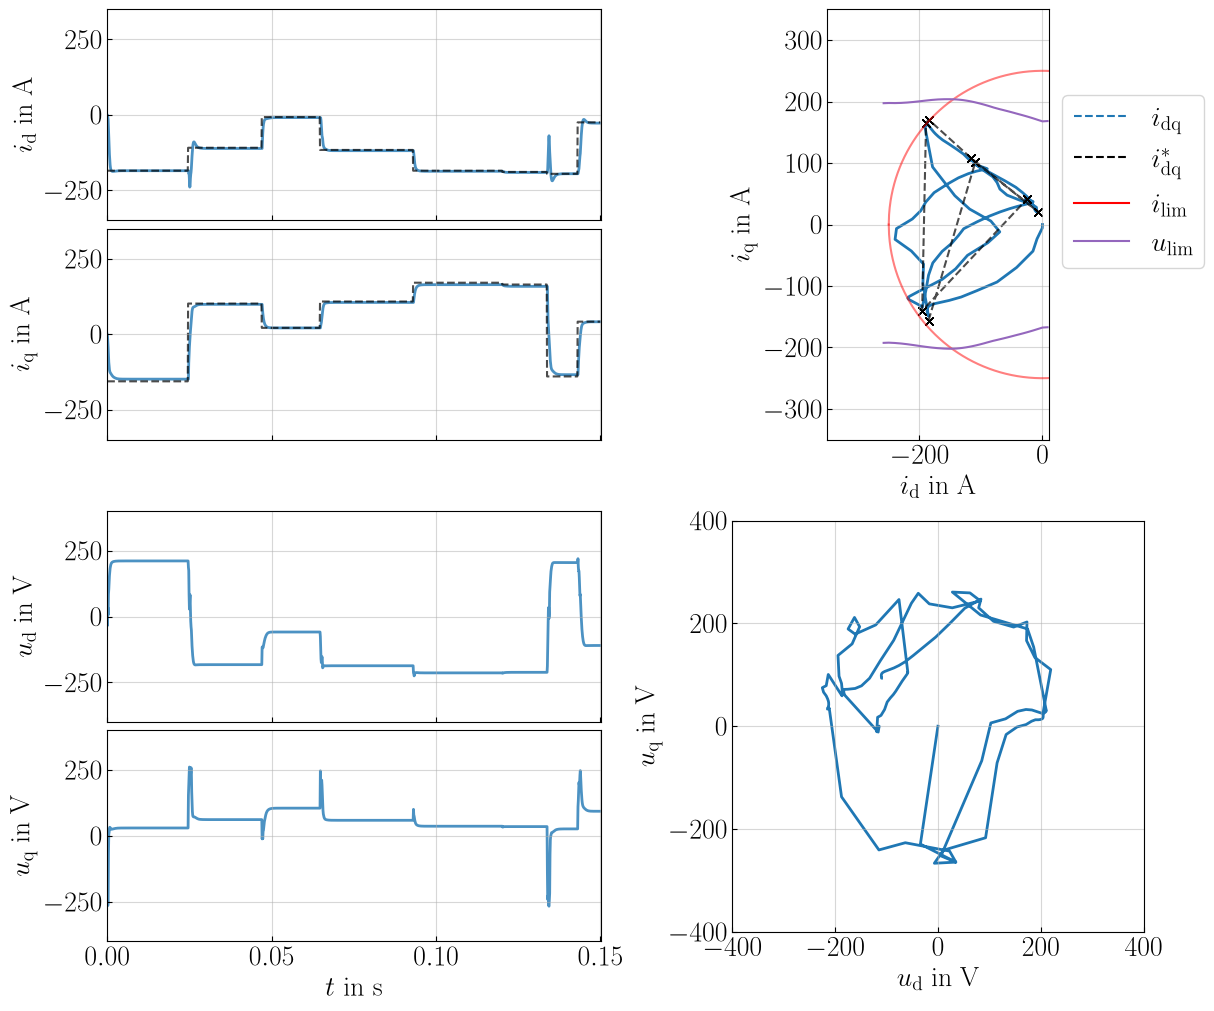

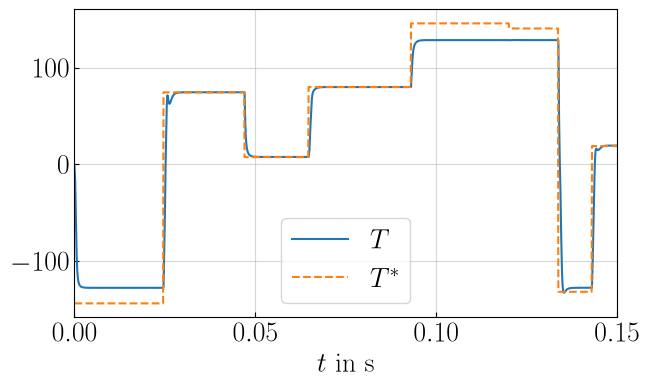

In [47]:
# compute reference
sequence_length = 1_500
T_ref_sequence = aprbs(sequence_length, 1, t_min=50, t_max=300, key=jax.random.key(12)).T[0] * 150

n = 5000

# run simulation
i_dq_sequence, u_dq_sequence, i_dq_ref_sequence, state = simulate_controller_plant_interaction(
    pmsm=pmsm,
    controller=current_controller,
    T_ref_sequence=T_ref_sequence,
    n=n,
)

# visualize results
fig,all_axes = visualize_trajectories_with_reference(
    i_dq_sequences=[i_dq_sequence],
    u_dq_sequences=[u_dq_sequence], 
    i_dq_ref_sequence=i_dq_ref_sequence,
    T_s_list=[pmsm.T_s],
    omegas=[state.physical_state.omega_el],
    ode=None,
    params=pmsm.env_properties.static_params,
)
add_voltage_constraint_to_ax(all_axes[4], n=n, color="tab:purple", pmsm=pmsm)

all_axes[4].legend(
    handles=[
        mlines.Line2D([], [], color="tab:blue", linestyle="dashed", linewidth=1.5, label=r"$i_\mathrm{dq}$"),
        mlines.Line2D([], [], color="k", linestyle="dashed", linewidth=1.5, label=r"$i_\mathrm{dq}^*$"),
        mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$"),
        mlines.Line2D([], [], color="tab:purple", linewidth=1.5, label=r"$u_\mathrm{lim}$"),
    ],
    bbox_to_anchor=[1.0, 0.6],
)

torque_sequence = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(
    i_dq_sequence[1:, 0], i_dq_sequence[1:, 1]
)

t = jnp.linspace(0, (pmsm.T_s * sequence_length), sequence_length)

fig, ax = plt.subplots(1,1, figsize=(7, 4))


ax.plot(t, torque_sequence, color="tab:blue", label=r"$T$")
ax.plot(t, T_ref_sequence, linestyle="dashed", color="tab:orange", label=r"$T^*$")
ax.set_xlim(t[0], t[-1])

ax.grid(True, alpha=0.5)
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")
ax.set_xlabel("$t$ in s")
ax.legend()
plt.show()

- `n = 11000` (maximum rpm):

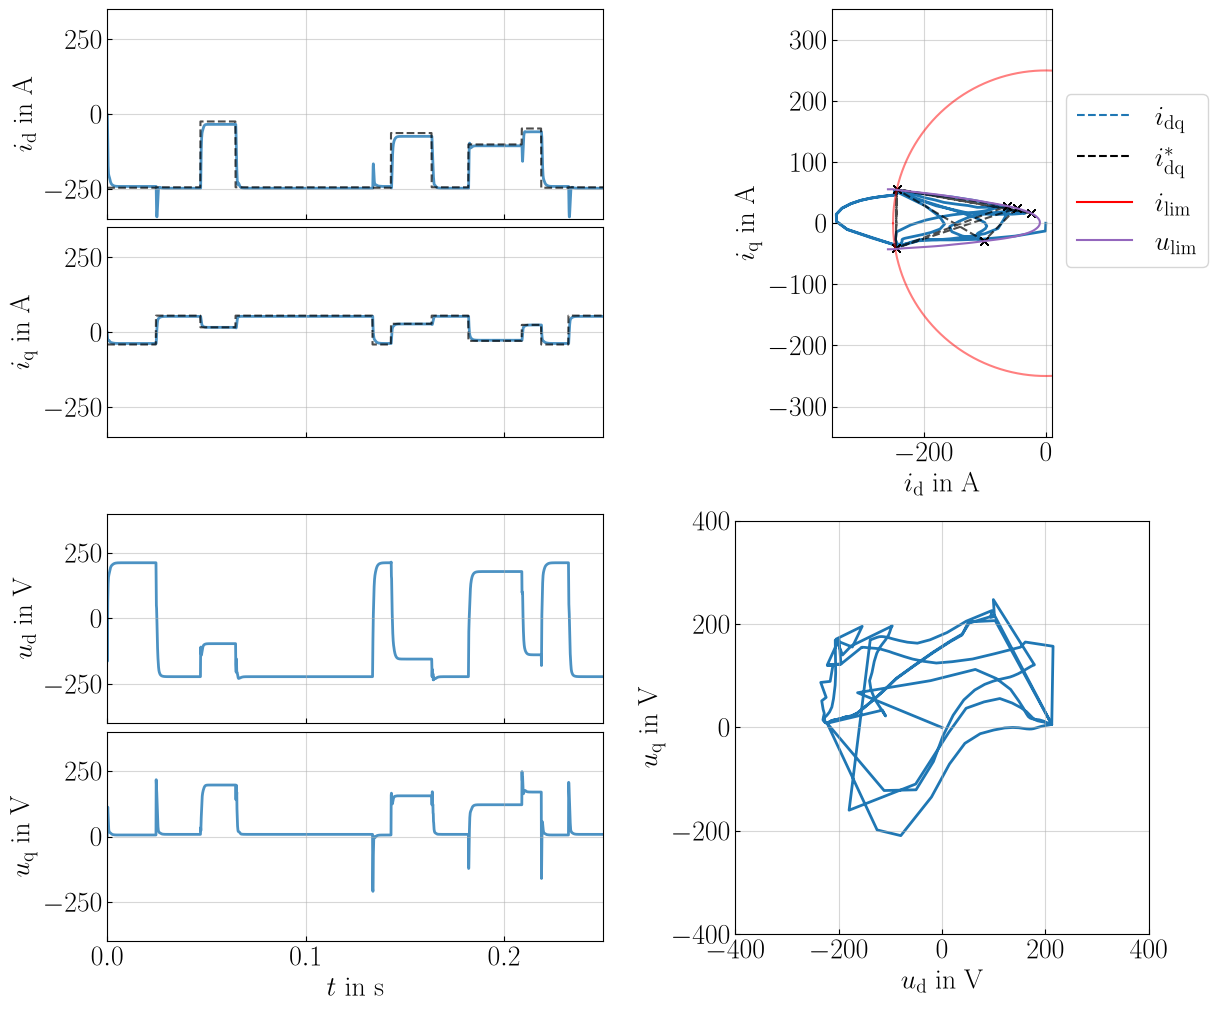

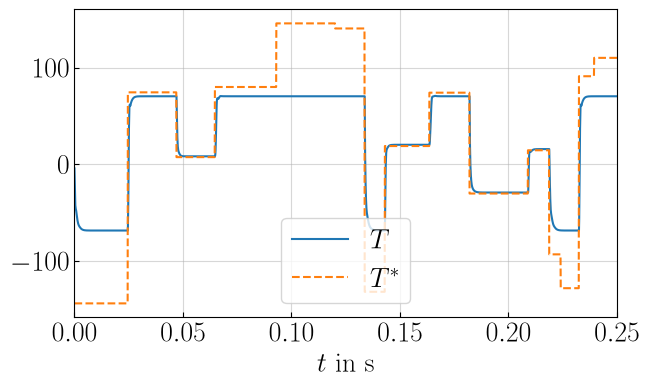

In [48]:
# compute reference
sequence_length = 2500
T_ref_sequence = aprbs(sequence_length, 1, t_min=50, t_max=300, key=jax.random.key(12)).T[0] * 150

n = 11000

# run simulation
i_dq_sequence, u_dq_sequence, i_dq_ref_sequence, state = simulate_controller_plant_interaction(
    pmsm=pmsm,
    controller=current_controller,
    T_ref_sequence=T_ref_sequence,
    n=n,
)

# visualize results
fig, all_axes = visualize_trajectories_with_reference(
    i_dq_sequences=[i_dq_sequence],
    u_dq_sequences=[u_dq_sequence], 
    i_dq_ref_sequence=i_dq_ref_sequence,
    T_s_list=[pmsm.T_s],
    omegas=[state.physical_state.omega_el],
    ode=None,
    params=pmsm.env_properties.static_params,
)
add_voltage_constraint_to_ax(all_axes[4], n=n, color="tab:purple", pmsm=pmsm)
all_axes[4].legend(
    handles=[
        mlines.Line2D([], [], color="tab:blue", linestyle="dashed", linewidth=1.5, label=r"$i_\mathrm{dq}$"),
        mlines.Line2D([], [], color="k", linestyle="dashed", linewidth=1.5, label=r"$i_\mathrm{dq}^*$"),
        mlines.Line2D([], [], color="red", linewidth=1.5, label=r"$i_\mathrm{lim}$"),
        mlines.Line2D([], [], color="tab:purple", linewidth=1.5, label=r"$u_\mathrm{lim}$"),
    ],
    bbox_to_anchor=[1.0, 0.6],
)

torque_sequence = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(
    i_dq_sequence[1:, 0], i_dq_sequence[1:, 1]
)

t = jnp.linspace(0, (pmsm.T_s * sequence_length), sequence_length)

fig, ax = plt.subplots(1,1, figsize=(7, 4))


ax.plot(t, torque_sequence, color="tab:blue", label=r"$T$")
ax.plot(t, T_ref_sequence, linestyle="dashed", color="tab:orange", label=r"$T^*$")
ax.set_xlim(t[0], t[-1])

ax.grid(True, alpha=0.5)
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")
ax.set_xlabel("$t$ in s")
ax.legend()
plt.show()

Here, we can see that some of the requested torques cannot be achieved for the operating speed. Therefore, the current operating points are adapted by the OPS to stay within the voltage ellipse.

The resulting torque $T^*_\mathrm{cc}$ is the maximum torque we can achieve for the given speed:

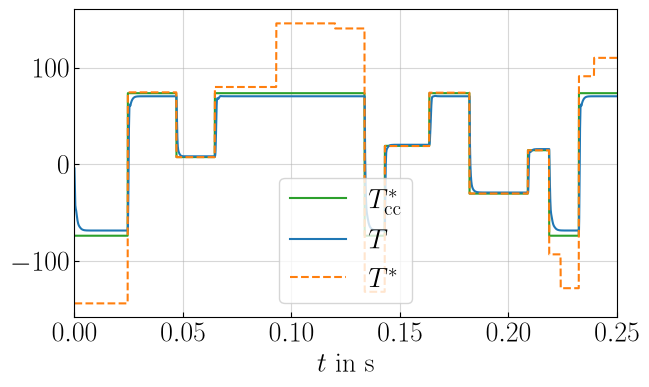

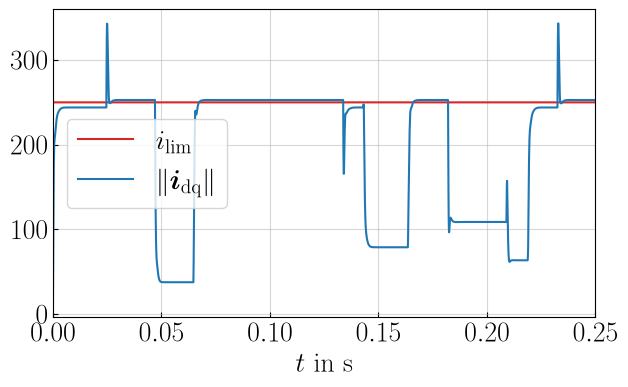

In [49]:
i_dq_ref_sequence, (flux_max, flux_target_lim, torque_max, torque_target_lim) = eqx.filter_vmap(
        get_current_operating_point, in_axes=(0, None, None)
)(T_ref_sequence, state.physical_state.omega_el, pmsm)

torque_target_sequence = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(
    i_dq_ref_sequence[:, 0], i_dq_ref_sequence[:, 1]
)

torque_sequence = eqx.filter_vmap(pmsm.currents_to_torque_saturated)(
    i_dq_sequence[1:, 0], i_dq_sequence[1:, 1]
)

t = jnp.linspace(0, (pmsm.T_s * sequence_length), sequence_length)

fig, ax = plt.subplots(1,1, figsize=(7, 4))

ax.plot(t, torque_target_sequence, color="tab:green", label=r"$T^*_\mathrm{cc}$")
ax.plot(t, torque_sequence, color="tab:blue", label=r"$T$")
ax.plot(t, T_ref_sequence, linestyle="dashed", color="tab:orange", label=r"$T^*$")
ax.set_xlim(t[0], t[-1])

ax.grid(True, alpha=0.5)
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")
ax.set_xlabel("$t$ in s")
ax.legend()
plt.show()

t = jnp.linspace(0, (pmsm.T_s * sequence_length), sequence_length)

fig, ax = plt.subplots(1,1, figsize=(7, 4))

ax.plot(t, jnp.ones(t.shape) * pmsm.env_properties.static_params.i_lim, color="tab:red", label=r"$i_\mathrm{lim}$")
ax.plot(t, jnp.linalg.norm(i_dq_sequence[1:], axis=-1), color="tab:blue", label=r"$\|\boldsymbol{i}_\mathrm{dq}\|$")
ax.set_xlim(t[0], t[-1])

ax.grid(True, alpha=0.5)
ax.tick_params(which="major", axis="y", direction="in")
ax.tick_params(which="both", axis="x", direction="in")
ax.set_xlabel("$t$ in s")
ax.legend()
plt.show()

So we can see that the current controller properly tracks the targeted current and the OPS also does its job to provide a feasible operating point.

The requested torque was simply not achievable and the next best operating point is chosen, which lies at the current limit in this case (**MC**-operating point).